<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/stellar_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spectral Analysis of Stars (with SSDS)**

In [ ]:
!pip install astroquery astropy matplotlib -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astroquery.sdss import SDSS
from astropy.io import fits

#### **Import SSDS data**

The code reads a FITS file containing the stellar spectrum's wavelength and flux data. We use data from the Sloan Digital Sky Survey (SDSS)

In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy import units as u

# Define the target coordinates (replace with your desired coordinates)
ra = 148.97083333
dec = 16.43222222

# Create a SkyCoord object
pos = coords.SkyCoord(ra=ra, dec=dec, unit='deg')

# Query SDSS for spectra
xid = SDSS.query_region(pos, spectro=True, radius=0.02 * u.deg)

# Check if any spectra were found
if xid is not None and len(xid) > 0:
    # Extract the identifiers from the first result (you can iterate if there are multiple)
    plate = xid['plate'][0]
    mjd = xid['mjd'][0]
    fiberID = xid['fiberID'][0]

    # Retrieve the spectrum using the identifiers
    sp = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberID)

    # Access the spectrum data
    flux = sp[0][1].data['flux']
    wavelength = 10**sp[0][1].data['loglam']

    # Print the first few data points (for demonstration)
    print("Wavelength (Angstroms) | Flux")
    for i in range(5):
        print(f"{wavelength[i]:.2f} | {flux[i]:.2f}")

else:
    print("No spectra found in the queried region.")

Wavelength (Angstroms) | Flux
3578.49 | 17.94
3579.32 | 13.18
3580.14 | 8.41
3580.96 | 2.94
3581.79 | 0.06


#### **Understand the Data**

In [ ]:
# Print the FITS Header Information
print(sp[0][1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   32 / length of dimension 1                          NAXIS2  =                 4573 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    8 / number of table fields                         TTYPE1  = 'flux    '                                                            TFORM1  = 'E       '                                                            TTYPE2  = 'loglam  '                                                            TFORM2  = 'E       '                                                            TTYPE3  = 'ivar    '                    

In [ ]:
# Print shape and data types
print("Flux shape:", flux.shape)
print("Flux data type:", flux.dtype)
print("Wavelength shape:", wavelength.shape)
print("Wavelength data type:", wavelength.dtype)

Flux shape: (4573,)
Flux data type: >f4
Wavelength shape: (4573,)
Wavelength data type: float32


In [ ]:
# Create an astropy Table
spectrum_table = Table([wavelength, flux], names=['wavelength', 'flux'])

# Print the first few rows
print(spectrum_table[:5])

wavelength    flux   
---------- ----------
 3578.4915  17.944094
 3579.3167  13.178341
   3580.14   8.412274
 3580.9636  2.9396217
 3581.7893 0.06172952


#### **Visualize the Spectrum**

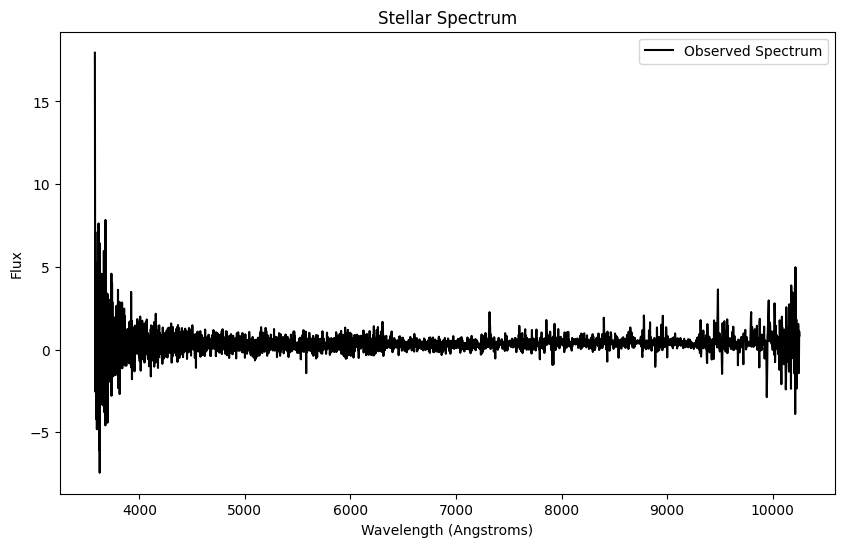

In [ ]:
# 2. Visualize the Spectrum
plt.figure(figsize=(10, 6))
plt.plot(wavelength, flux, 'k-', label='Observed Spectrum')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux')
plt.title('Stellar Spectrum')
plt.legend()
plt.show()

#### **Identify Spectral Lines**

A simplified method finds potential absorption lines based on a flux threshold.


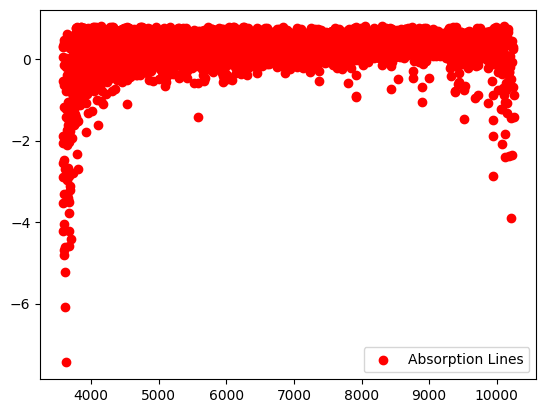

In [ ]:
# 3. Identify Spectral Lines (Simplified)
# In reality, you'd use line lists and sophisticated algorithms
absorption_lines = np.where(flux < 0.8)[0]  # Assuming strong lines have flux < 0.8
plt.scatter(wavelength[absorption_lines], flux[absorption_lines], color='r', marker='o', label='Absorption Lines')
plt.legend()
plt.show()

#### **Fit a Spectral Line (Example: Gaussian)**

A Gaussian function is fitted to a specific region of the spectrum. In real research, you'd use more complex models and fitting techniques. In this example, we estimate the initial guess for the parameters based on the data in the fitting region and increase maxfev to 2000.



In [ ]:
# 4. Fit a Spectral Line (Example: Gaussian)
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) / stddev)**2 / 2)

line_region = np.where((wavelength > 6550) & (wavelength < 6570))[0]

# Estimate initial guess from the data
estimated_amplitude = np.min(flux[line_region])  # Assuming absorption line
estimated_mean = wavelength[line_region][np.argmin(flux[line_region])]
estimated_stddev = 5  # Adjust based on visual inspection

p0 = [estimated_amplitude, estimated_mean, estimated_stddev]

popt, pcov = curve_fit(gaussian, wavelength[line_region], flux[line_region], p0=p0, maxfev=2000)

#### **Interpret Results**

The fitted line parameters (amplitude, central wavelength, width) provide insights into the star's properties (e.g., temperature, chemical composition, radial velocity). The fit is also plotted for visual inspection.

Fitted Line Parameters:
Amplitude: 94.4659544142871
Central Wavelength: 1922.600079171807
Line Width (Std Dev): 1397.6795680982566


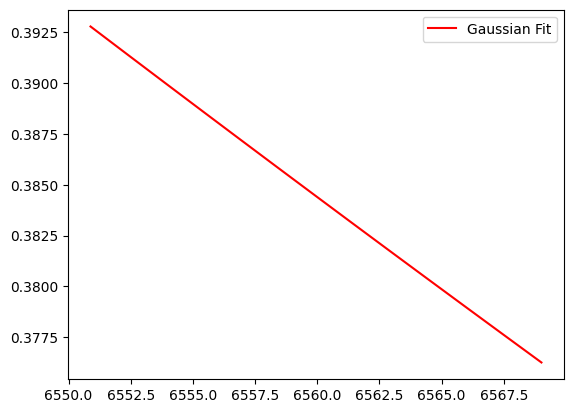

In [ ]:
# 5. Interpret Results
print("Fitted Line Parameters:")
print("Amplitude:", popt[0])
print("Central Wavelength:", popt[1])
print("Line Width (Std Dev):", popt[2])

plt.plot(wavelength[line_region], gaussian(wavelength[line_region], *popt), 'r-', label='Gaussian Fit')
plt.legend()
plt.show()